# Monte Carlo Simulation for Option Pricing

Monte Carlo Simulation is a statistical technique used to model the probability of different outcomes in a process that cannot be easily predicted due to the inherent randomness or complexity of the system. In the context of **option pricing**, Monte Carlo simulations are used to estimate the value of options, especially when closed-form solutions (like the Black-Scholes model) are not available or when the underlying asset follows complex paths.

## Key Concepts of Monte Carlo Simulation for Option Pricing

The core idea behind Monte Carlo simulation in option pricing is to simulate many possible paths of the underlying asset's price and use the average payoff of those simulated paths to estimate the option's price.

### Basic Steps Involved:f
1. **Simulate multiple paths**: Generate potential future prices of the underlying asset  
2. **Calculate payoff for each path**: Calculate the payoff at expiration
3. **Discount the payoff**: Discount back to present value
4. **Average the payoffs**: Average across all paths

## Monte Carlo Simulation Formula Details

### 1. Stock Price Simulation (Geometric Brownian Motion):

$dS = \mu S dt + \sigma S dZ$

Where:
- $S$ = stock price at time $t$
- $\mu$ = drift rate
- $\sigma$ = volatility
- $dZ$ = Wiener process increment

### 2. Option Payoff Calculations:

For Call Option:
$\text{Payoff} = \max(S_T - K, 0)$

For Put Option:
$\text{Payoff} = \max(K - S_T, 0)$

Where:
- $S_T$ = stock price at expiration
- $K$ = strike price

### 3. Option Price Calculation:

$\text{Option Price} = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \text{Payoff}_i$

Where:
- $r$ = risk-free rate
- $T$ = time to maturity
- $N$ = number of simulations
- $\text{Payoff}_i$ = payoff of $i$-th simulation

### Discretized Stock Price Path:

$S_{t+\Delta t} = S_t \exp\left((r - \frac{\sigma^2}{2})\Delta t + \sigma\sqrt{\Delta t}Z\right)$

Where:
- $\Delta t$ = time step
- $Z$ = standard normal random variable
- $r$ = risk-free rate



## Advantages and Limitations

### Advantages:
- Flexible for complex options
- Works without closed-form solutions
- Handles multiple risk factors

### Limitations:
- Computationally expensive
- Slow convergence
- Higher error bounds than analytical solutions


## Statistical Measures in Monte Carlo Simulation

### Standard Deviation of Option Prices

For $N$ simulations, the sample standard deviation is given by:

$\sigma_{MC} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (V_i - \bar{V})^2}$

Where:
- $V_i$ = discounted payoff from the $i$-th simulation
- $\bar{V}$ = mean of all discounted payoffs
- $N$ = number of simulations

### Standard Error of the Estimate

The standard error of the Monte Carlo estimate is:

$SE = \frac{\sigma_{MC}}{\sqrt{N}}$

This gives us the standard deviation of our option price estimate.

### Confidence Intervals

For a 95% confidence interval:

$CI_{95\%} = \bar{V} \pm 1.96 \times SE$

For a 99% confidence interval:

$CI_{99\%} = \bar{V} \pm 2.576 \times SE$


### Convergence Rate

The convergence rate follows:

$\text{Error} \propto \frac{1}{\sqrt{N}}$

This means to reduce the error by a factor of 2, you need to increase the number of simulations by a factor of 4.


### Applications of Monte Carlo Simulation 
Monte Carlo simulation tends to be numerically more eﬃcient than other procedures
when there are three or more stochastic variables. This is because the time taken to
carry out a Monte Carlo simulation increases approximately linearly with the number
of variables, whereas the time taken for most other procedures increases exponentially
with the number of variables. One advantage of Monte Carlo simulation is that it can
provide a standard error for the estimates that it makes. Another is that it is an
approach that can accommodate complex payoﬀs and complex stochastic processes.
Also, it can be used when the payoﬀ depends on some function of the whole path
followed by a variable, not just its terminal value.



In [23]:
import numpy as np


In [24]:
class MonteCarlo:
    def __init__(self, N, M, S, K, r, sigma, T):
        """
        N: number of discrete time steps
        M: number of simulations/paths
        S: initial stock price
        K: strike price
        r: risk-free rate
        sigma: volatility
        T: time to maturity
        """
        self.N = N
        self.M = M
        self.S = S
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.dt = T / N  # time step

    def simulate_paths(self):
        """
        Simulate M paths of stock prices using geometric Brownian motion.
        Returns an array of terminal prices (ST) at maturity.
        """
        # Generate random normal increments for all paths
        Z = np.random.normal(0, 1, (self.M, self.N)) # shape (M, N) (each row represnts a path (strating from col j=0 to col j=N-1))
        lnS = np.log(self.S) + np.cumsum(
            (self.r - 0.5 * self.sigma ** 2) * self.dt + self.sigma * np.sqrt(self.dt) * Z,
            axis=1
        )
        #basically we want lnSt=lnSt-1 + (r-0.5*sigma^2)*dt + sigma*sqrt(dt)*Zt
        #and we repeat this N times to finally obtain lnST  
        # Return the terminal stock prices
        return np.exp(lnS[:, -1])# we return the last column of the matrix lnS

    def price_call(self):
        """
        Calculate the price of a call option.
        """
        ST = self.simulate_paths()
        CT = np.maximum(ST - self.K, 0)
        price = np.exp(-self.r * self.T) * np.mean(CT)
        standard_error = np.exp(-self.r * self.T) * np.std(CT, ddof=1) / np.sqrt(self.M)
        return price, standard_error

    def price_put(self):
        """
        Calculate the price of a put option.
        """
        ST = self.simulate_paths()
        PT = np.maximum(self.K - ST, 0)
        price = np.exp(-self.r * self.T) * np.mean(PT)
        standard_error = np.exp(-self.r * self.T) * np.std(PT, ddof=1) / np.sqrt(self.M)
        return price, standard_error


### Monte Carlo Simulation: Sensitivity of Error with Changing S and K

In this example, we explore the relationship between the values of \( S \) (initial stock price) and \( K \) (strike price) on the standard error of Monte Carlo option pricing. 

#### Key Observations:
- **Low \( S \) and \( K \):** 
  - With smaller values for \( S \) and \( K \), the simulated price paths are less sensitive to fluctuations.
  - The calculated option prices tend to exhibit lower standard errors as the sensitivity to small changes in the price path is reduced.

- **High \( S \) and \( K \):**
  - Increasing \( S \) and \( K \) makes the option price more sensitive to small variations in the simulated price paths.
  - As a result, the standard error increases because these fluctuations have a larger impact on the option value.

#### Explanation:
This behavior arises due to the increased sensitivity of price fluctuations when \( S \) and \( K \) are higher. In these cases:
- Small changes in the simulated price paths can result in disproportionately larger changes in the computed option payoff.
- This increased sensitivity amplifies the potential for error in the Monte Carlo calculation.

#### Experiment:
Below, we demonstrate the Monte Carlo simulation for:
1. **Low \( S \) and \( K \):** Minimal sensitivity, resulting in a smaller standard error.
2. **High \( S \) and \( K \):** Increased sensitivity, resulting in a larger standard error.

The results highlight the impact of \( S \) and \( K \) on the standard error and reinforce the importance of sufficient paths (\( M \)) to mitigate this effect in practice.


In [25]:
"""Calculating the realised volatility of the stock""" 
import yfinance as yf
from datetime import datetime as dt , timedelta as td
end_date = dt.today().strftime('%Y-%m-%d')
start_date = (dt.today()-td(days=365)).strftime('%Y-%m-%d')
# Fetch historical data for Nifty 50 (symbol: ^NSEI)
nifty = yf.download("^NSEI",start_date,end_date)
nifty['daily_return'] = nifty['Adj Close'].pct_change()
nifty.dropna(inplace=True)
daily_volatility = nifty['daily_return'].std()
annual_volatility = daily_volatility*np.sqrt(252)
print(f"Annualized Historical Volatility (last 1 year): {annual_volatility * 100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Annualized Historical Volatility (last 1 year): 14.28%


In [26]:
#Example with low S and K values
#If we increase S and K then error will increase due to increased sensitivity of price fluctuations
#meaning that small changes in the simulated price path can lead to larger changes in the option value, resulting in a larger potential for error in the calculation.

# initial derivative parameters
S = 101.15          #stock price
K = 98.01           #strike price
vol = annual_volatility        #volatility (%)
#use standard deviation of returns 
r = 0.01            #risk-free rate (%)
N = 10              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
M = 1000            #number of simulations
import datetime

T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
MC=MonteCarlo(N,M,S,K,r,vol,T)
call_price=MC.price_call()
print(call_price[0])
print(call_price[1])


3.533997811426974
0.10042115459177443


In [27]:
if __name__ == "__main__":
    #Testing on nifty
    # Example parameters
    S0 = 23707.90    # Current stock price
    K = 23700.00     # Strike price
    T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
    r = 0.06857    # Risk-free rate (6.857%)
    sigma = annual_volatility # Volatility 
    N = 1000              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
    M = 10000            #number of simulations  
    # Create Black-Scholes model instance
    mcs = MonteCarlo(N,M,S0, K, T, r, sigma)
    # Calculate option prices
    call_price, call_se  = mcs.price_call()
    put_price, put_se = mcs.price_put()
    # Print results
    print(f"Parameters:")
    print(f"Stock Price (S0): {S0}")
    print(f"Strike Price (K): {K}")
    print(f"Time to Expiration (T): {T} years")
    print(f"Risk-free Rate (r): {r*100}%")
    print(f"Volatility (σ): {sigma*100}%")
    print(f"\nOption Prices:")
    print(f"Number of Simulations: {M}")
    print(f"Number of Time Steps: {N}")
    print(f"Call Option Price: {call_price:.2f}")
    print(f"Put Option Price: {put_price:.2f}")
    print(f"\nStandard Errors:")
    print(f"Call Option: {call_se:.6f}")
    print(f"Put Option: {put_se:.6f}")




Parameters:
Stock Price (S0): 23707.9
Strike Price (K): 23700.0
Time to Expiration (T): 0.06575342465753424 years
Risk-free Rate (r): 6.857%
Volatility (σ): 14.283458029563084%

Option Prices:
Number of Simulations: 10000
Number of Time Steps: 1000
Call Option Price: 370.13
Put Option Price: 147.09

Standard Errors:
Call Option: 4.331367
Put Option: 2.744863


In [204]:
import requests
import pandas as pd

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
response = session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies

response = session.get(url, headers=headers)
data = response.json() # Parse JSON data

"""
data is a dictionary with keys: 'records' and 'filtered'

records contains complete, unfiltered data from the Nifty Option Chain API.
Structure:
data: A list of all option chain entries (calls and puts) across various expiry dates and strike prices.
expiryDates: A list of all available expiry dates.
timestamp: The timestamp of when the data was fetched.
underlyingValue: The current price of the NIFTY index.

filtered contains a pre-filtered subset of the option chain data. It focuses on the nearest expiry date and relevant strike prices close to the current NIFTY value
Structure:
CE: Filtered Call Option data.
PE: Filtered Put Option data.
data: Limited to strikes near the current NIFTY index (e.g., ±10 strikes around the spot price).
"""

# User-defined expiry date
TARGET_EXPIRY = '30-Jan-2025'  # desired expiry date

# Parse data
options_data = []
for record in data['records']['data']: # record contains expiryDate, strikePrice, CE, PE
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:  # Filter by specific expiry date
        strike_price = record['strikePrice']
        ltp_call = record.get('CE', {}).get('lastPrice', None)  # Call Option LTP
        ltp_put = record.get('PE', {}).get('lastPrice', None)   # Put Option LTP
        iv_call = record.get('CE', {}).get('impliedVolatility', None)
        iv_put = record.get('PE', {}).get('impliedVolatility', None)
        options_data.append({
            'expiry_date': expiry_date,
            'strike': strike_price,
            'ltp_call': ltp_call,
            'ltp_put': ltp_put,
            'iv_call': iv_call,
            'iv_put': iv_put,
        })

# Convert to DataFrame
df = pd.DataFrame(options_data)
if df.empty:
    print(f"No data found for expiry date: {TARGET_EXPIRY}")
else:
    print(f"Data fetched successfully for expiry date: {TARGET_EXPIRY}")

print(df)


Data fetched successfully for expiry date: 30-Jan-2025
    expiry_date  strike  ltp_call  ltp_put  iv_call  iv_put
0   30-Jan-2025   21600   1915.00     8.20     0.00   18.51
1   30-Jan-2025   21650      0.00     9.40     0.00   18.57
2   30-Jan-2025   21700   1794.90    10.40     0.00   18.37
3   30-Jan-2025   21750      0.00    11.15     0.00   18.17
4   30-Jan-2025   21800   1831.80    11.85    27.83   17.92
..          ...     ...       ...      ...      ...     ...
94  30-Jan-2025   26300      4.15  2754.30    20.40   27.18
95  30-Jan-2025   26350      4.10     0.00    20.70    0.00
96  30-Jan-2025   26400      3.90  2752.50    20.85    0.00
97  30-Jan-2025   26450      3.95     0.00    21.21    0.00
98  30-Jan-2025   26500      3.85  2965.25    21.41   30.73

[99 rows x 6 columns]


In [205]:
S=data['records']['underlyingValue']    # Current stock price
r = 0.06857    # Risk-free rate (6.857%)
sigma = annual_volatility # Volatility 
expiry_date = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
today = dt.today()
T = (expiry_date - today).days / 365 + 1 / 365
N = 100              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
M = 1000            #number of simulations
df = df[(df['strike'] >= 23450) & (df['strike'] <= 24800)]
# Assuming price_call returns two values: (price, error)
df['mcs_call_price'], df['err_call'] = zip(*df['strike'].apply(
    lambda K: MonteCarlo(N, M, S, K, r, sigma, T).price_call())
)
df['mcs_put_price'], df['err_put'] = zip(*df['strike'].apply(
    lambda K: MonteCarlo(N, M, S, K, r, sigma, T).price_put())
)
df.columns
# MonteCarlo(N, M, 23700, 23600, r, sigma, T).price_call()

Index(['expiry_date', 'strike', 'ltp_call', 'ltp_put', 'iv_call', 'iv_put',
       'mcs_call_price', 'err_call', 'mcs_put_price', 'err_put'],
      dtype='object')

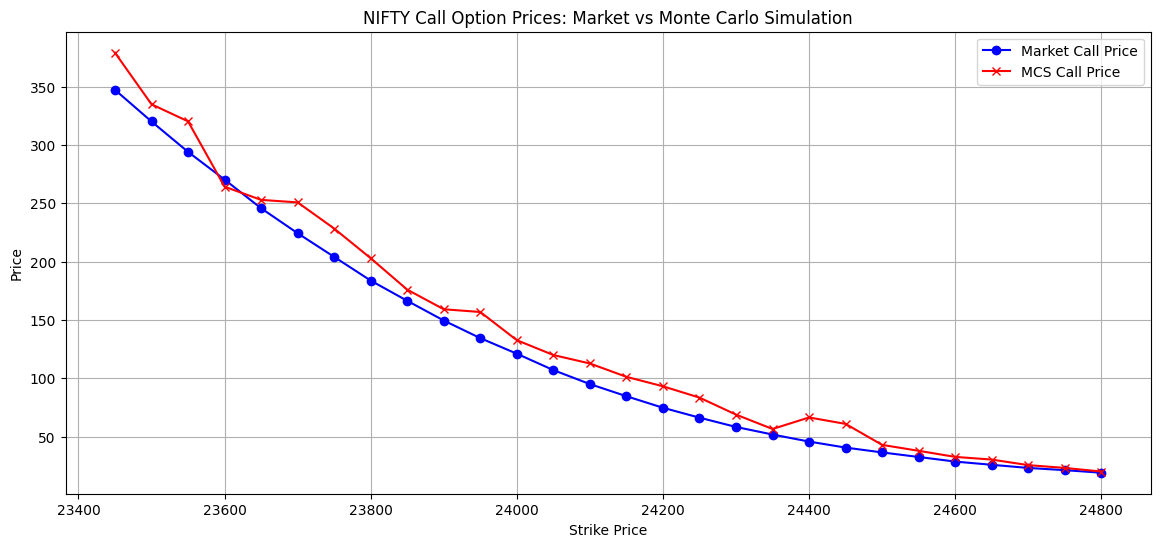

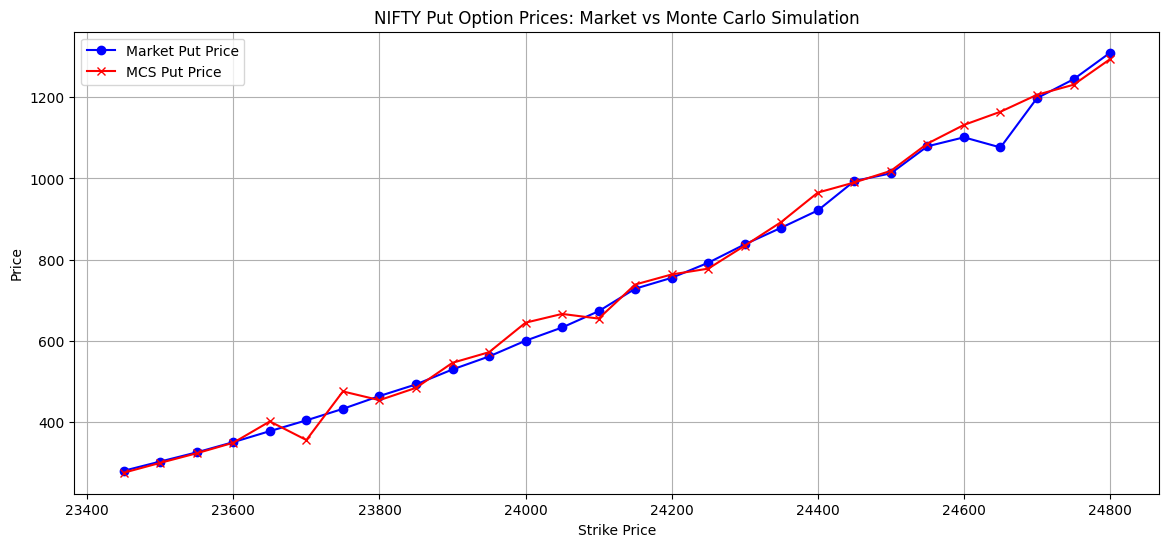

In [206]:
import matplotlib.pyplot as plt

# Plot Call Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price', color='b')
plt.plot(df['strike'], df['mcs_call_price'], 'x-', label='MCS Call Price', color='r')
plt.title('NIFTY Call Option Prices: Market vs Monte Carlo Simulation')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Put Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_put'], 'o-', label='Market Put Price', color='b')
plt.plot(df['strike'], df['mcs_put_price'], 'x-', label='MCS Put Price', color='r')
plt.title('NIFTY Put Option Prices: Market vs Monte Carlo Simulation')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


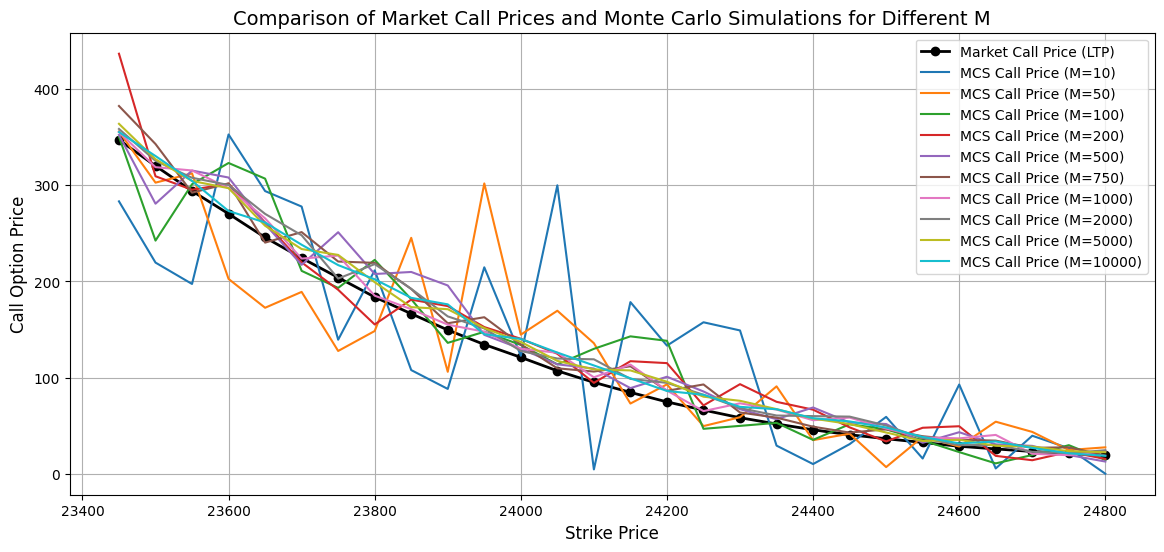

In [207]:
# Define a range of N values to test
M_values = [10, 50, 100, 200,500,750,1000,2000,5000,10000]  # Different numbers of time steps

# Create a new DataFrame to store mcs_call_price for each N
for M in M_values:
    df[f'mcs_call_price_M{M}'] = df['strike'].apply(
        lambda K: MonteCarlo(N, M, S, K, r, sigma, T).price_call()[0]
    )

# Plot the call option prices
plt.figure(figsize=(14, 6))

# Plot the actual market prices (ltp_call)
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black', linewidth=2)

# Plot the Monte Carlo prices for different N values
for M in M_values:
    plt.plot(df['strike'], df[f'mcs_call_price_M{M}'], label=f'MCS Call Price (M={M})')

# Add title and labels
plt.title('Comparison of Market Call Prices and Monte Carlo Simulations for Different M', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [208]:
import plotly.graph_objects as go

fig = go.Figure()

# Add market prices
fig.add_trace(go.Scatter(x=df['strike'], y=df['ltp_call'], mode='lines+markers',
                         name='Market Call Price (LTP)', line=dict(color='black', width=2)))

# Add Monte Carlo prices for each M
for M in M_values:
    fig.add_trace(go.Scatter(x=df['strike'], y=df[f'mcs_call_price_M{M}'], mode='lines',
                             name=f'MCS Call Price (M={M})'))

# Update layout for better visualization
fig.update_layout(
    title='Comparison of Market Call Prices and Monte Carlo Simulations for Different M',
    xaxis_title='Strike Price',
    yaxis_title='Call Option Price',
    legend_title='Price Source',
    template='plotly_white'
)

fig.show()


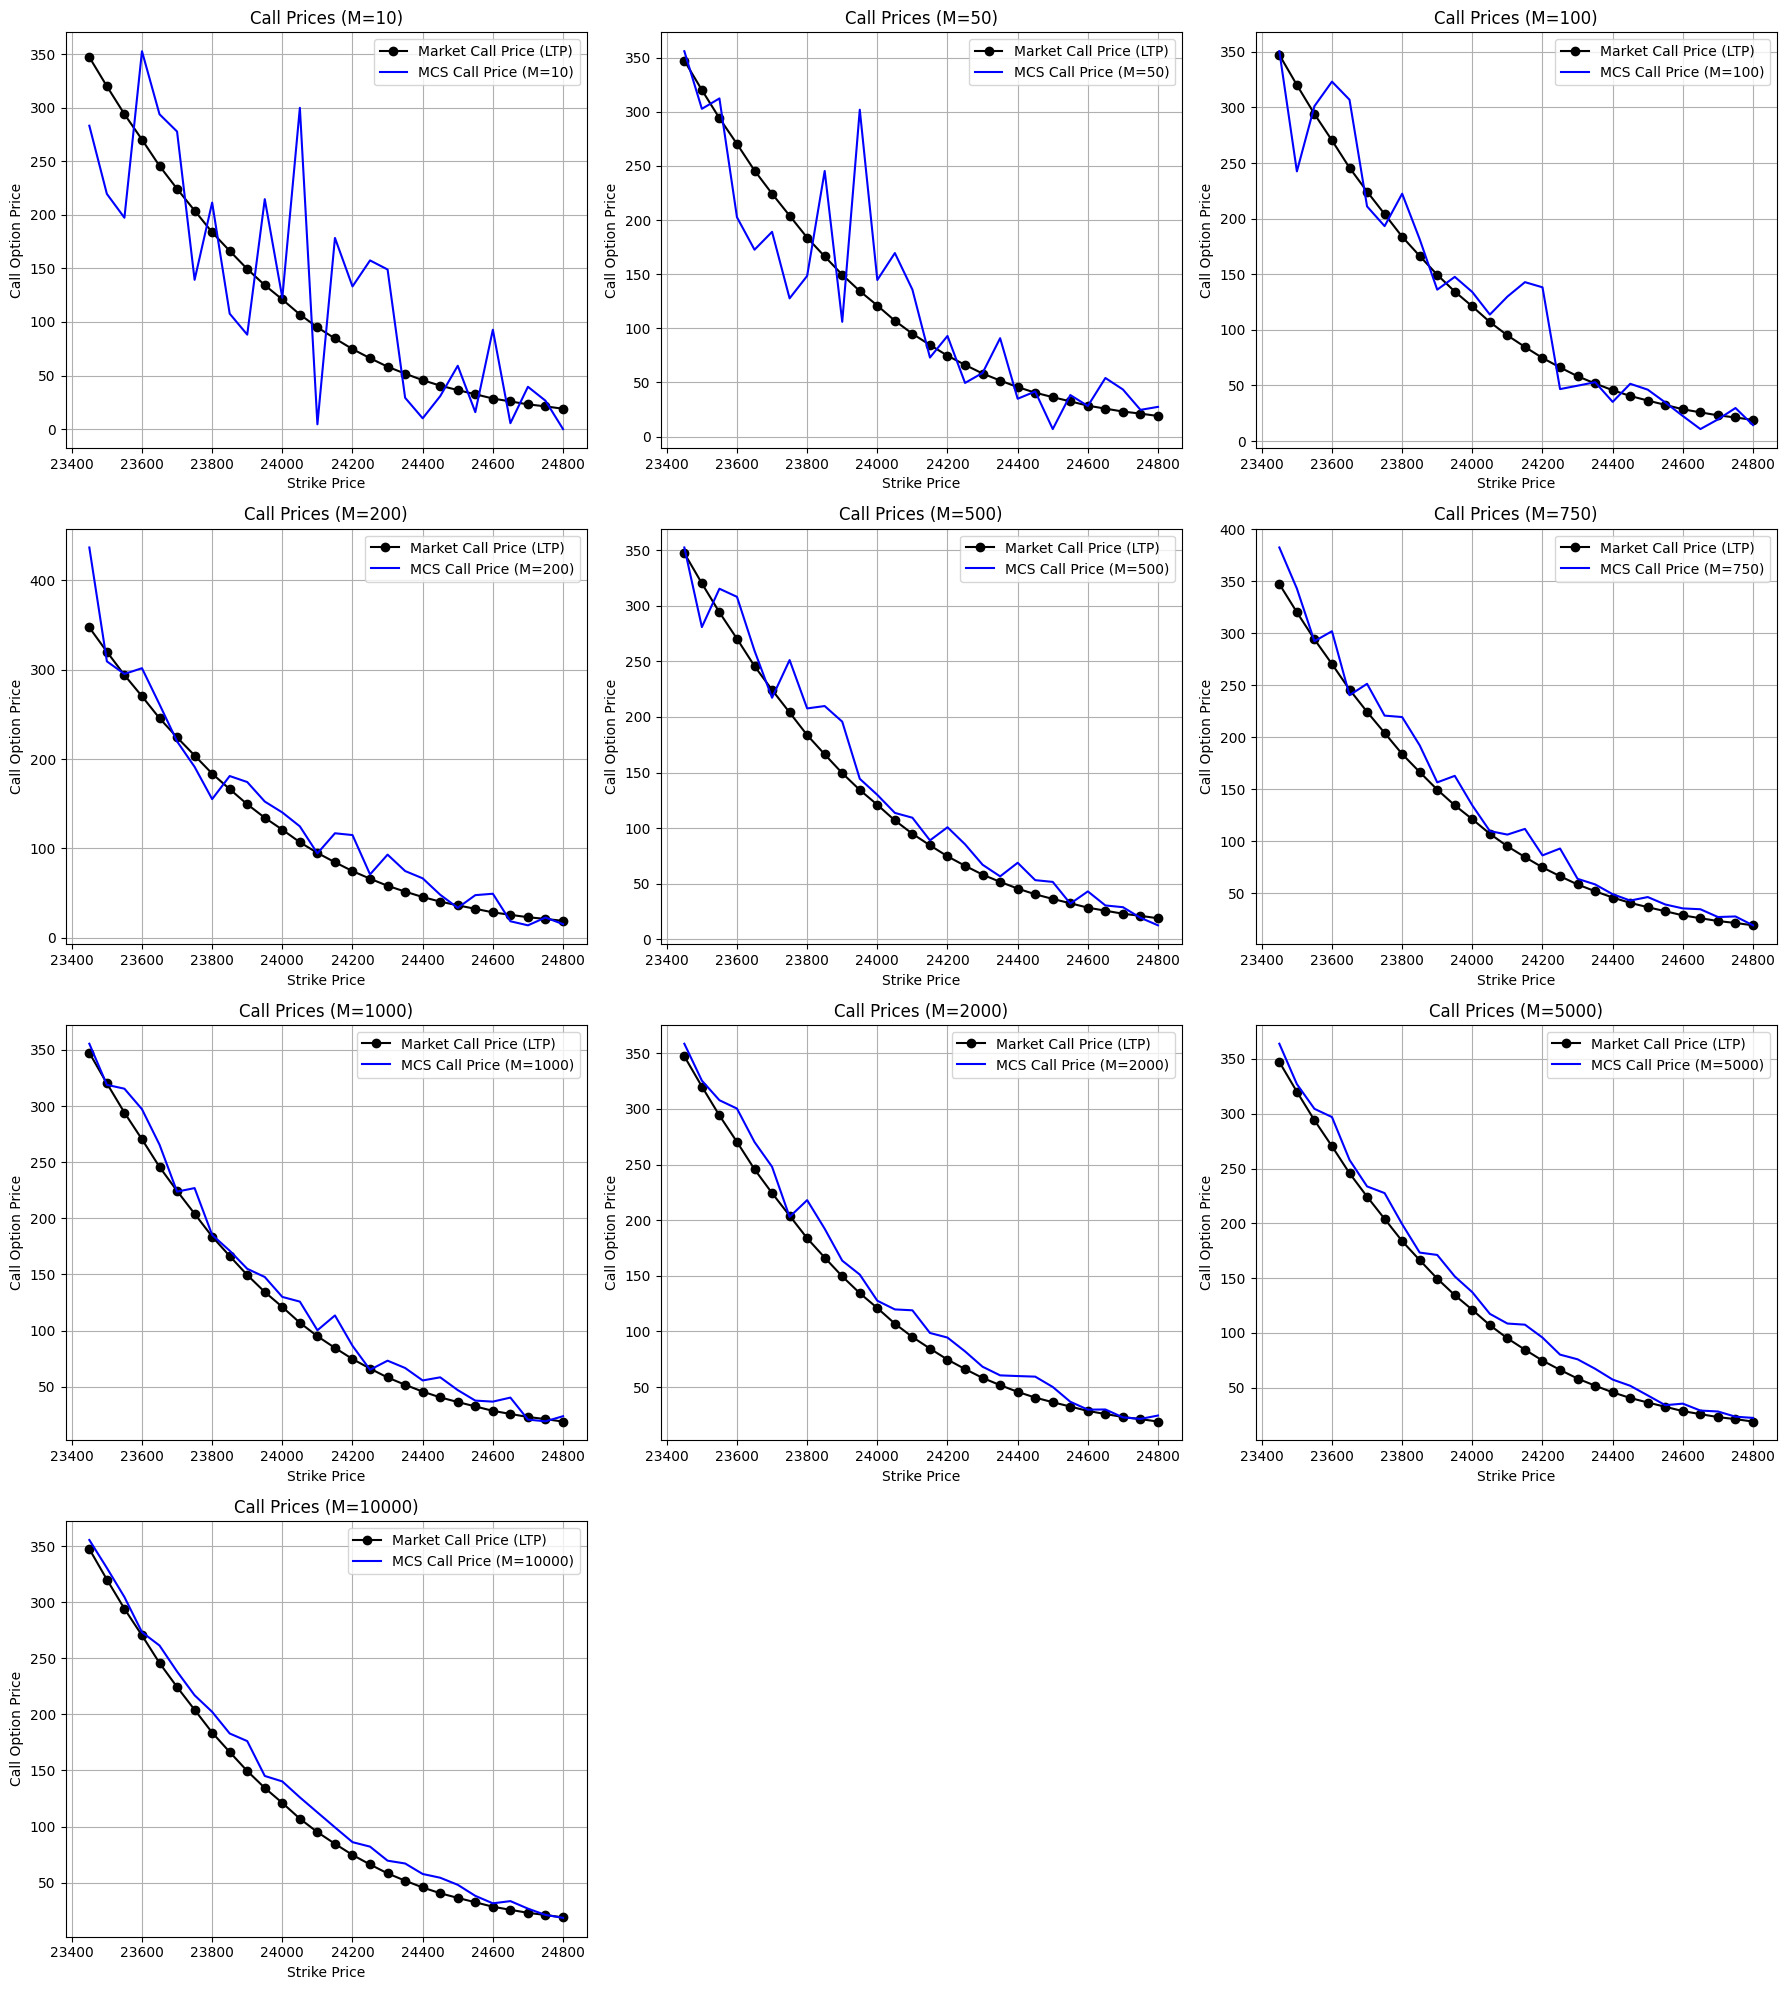

In [209]:
import matplotlib.pyplot as plt

# Number of subplots based on N_values
rows = (len(M_values) + 2) // 3  # Adjust to fit 3 columns per row

fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))  # 3 columns
axes = axes.flatten()

# Plot each N in a separate subplot
for i, M in enumerate(M_values):
    axes[i].plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black')
    axes[i].plot(df['strike'], df[f'mcs_call_price_M{M}'], label=f'MCS Call Price (M={M})', color='blue')
    axes[i].set_title(f'Call Prices (M={M})', fontsize=12)
    axes[i].set_xlabel('Strike Price', fontsize=10)
    axes[i].set_ylabel('Call Option Price', fontsize=10)
    axes[i].legend()
    axes[i].grid(True)

# Hide unused subplots
for j in range(len(M_values), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


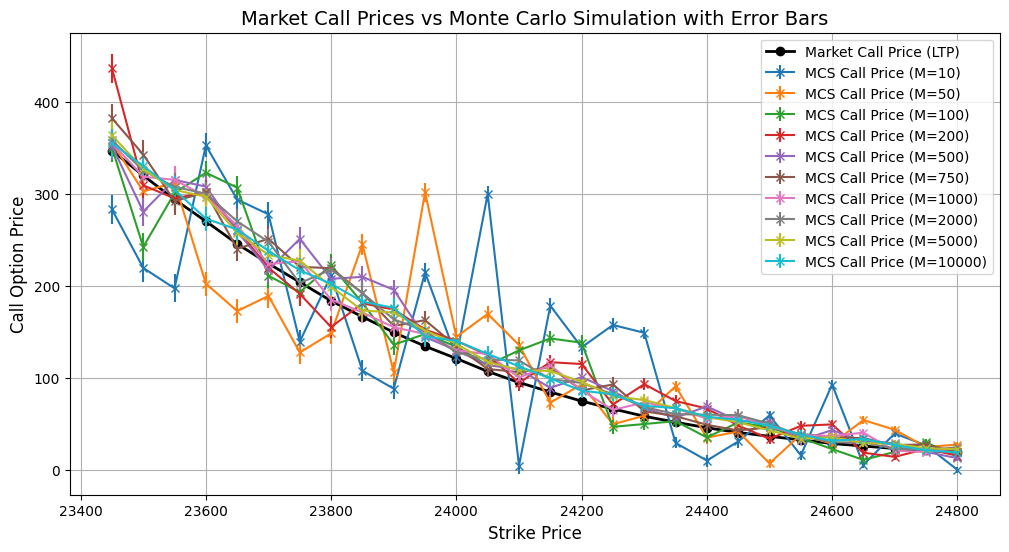

In [210]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot market prices
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black', linewidth=2)

# Plot Monte Carlo prices with error bars for selected N values
selected_M = [10, 50, 100, 200,500,750,1000,2000,5000,10000]  # Different numbers of time steps

for M in selected_M:
    plt.errorbar(df['strike'], df[f'mcs_call_price_M{M}'], yerr=df['err_call'], fmt='x-', label=f'MCS Call Price (M={M})')

# Add titles and legend
plt.title('Market Call Prices vs Monte Carlo Simulation with Error Bars', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


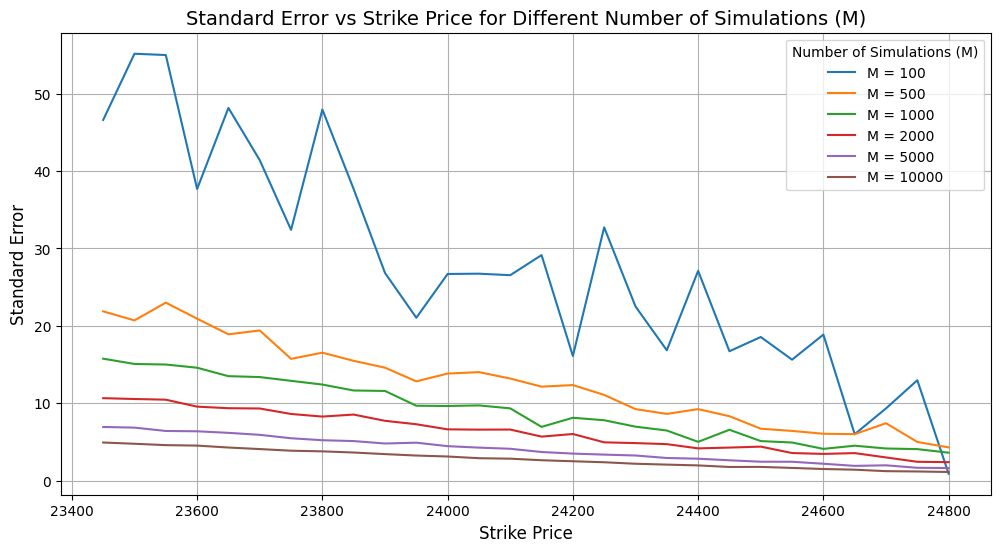

In [211]:
import numpy as np
import matplotlib.pyplot as plt

# Define different M values (number of simulations)
M_values = [100, 500, 1000, 2000, 5000, 10000]

# Calculate standard errors for each M and store them in new columns
for M in M_values:
    df[f'err_call_M{M}'] = df['strike'].apply(
        lambda K: MonteCarlo(N, M, S, K, r, sigma, T).price_call()[1]
    )

# Plot standard error vs strike price for different M values
plt.figure(figsize=(12, 6))
for M in M_values:
    plt.plot(df['strike'], df[f'err_call_M{M}'], label=f'M = {M}')

# Add titles and labels
plt.title('Standard Error vs Strike Price for Different Number of Simulations (M)', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Standard Error', fontsize=12)
plt.legend(title='Number of Simulations (M)', fontsize=10)
plt.grid(True)
plt.show()


In [212]:
import plotly.graph_objects as go

fig = go.Figure()
for M in M_values:
    fig.add_trace(go.Scatter(x=df['strike'], y=df[f'err_call_M{M}'], mode='lines',
                             name=f'Standard Error (M={M})'))

fig.update_layout(
    title='Standard Error vs Strike Price for Different M',
    xaxis_title='Strike Price',
    yaxis_title='Standard Error',
    legend_title='Simulations (M)',
    template='plotly_white'
)
fig.show()


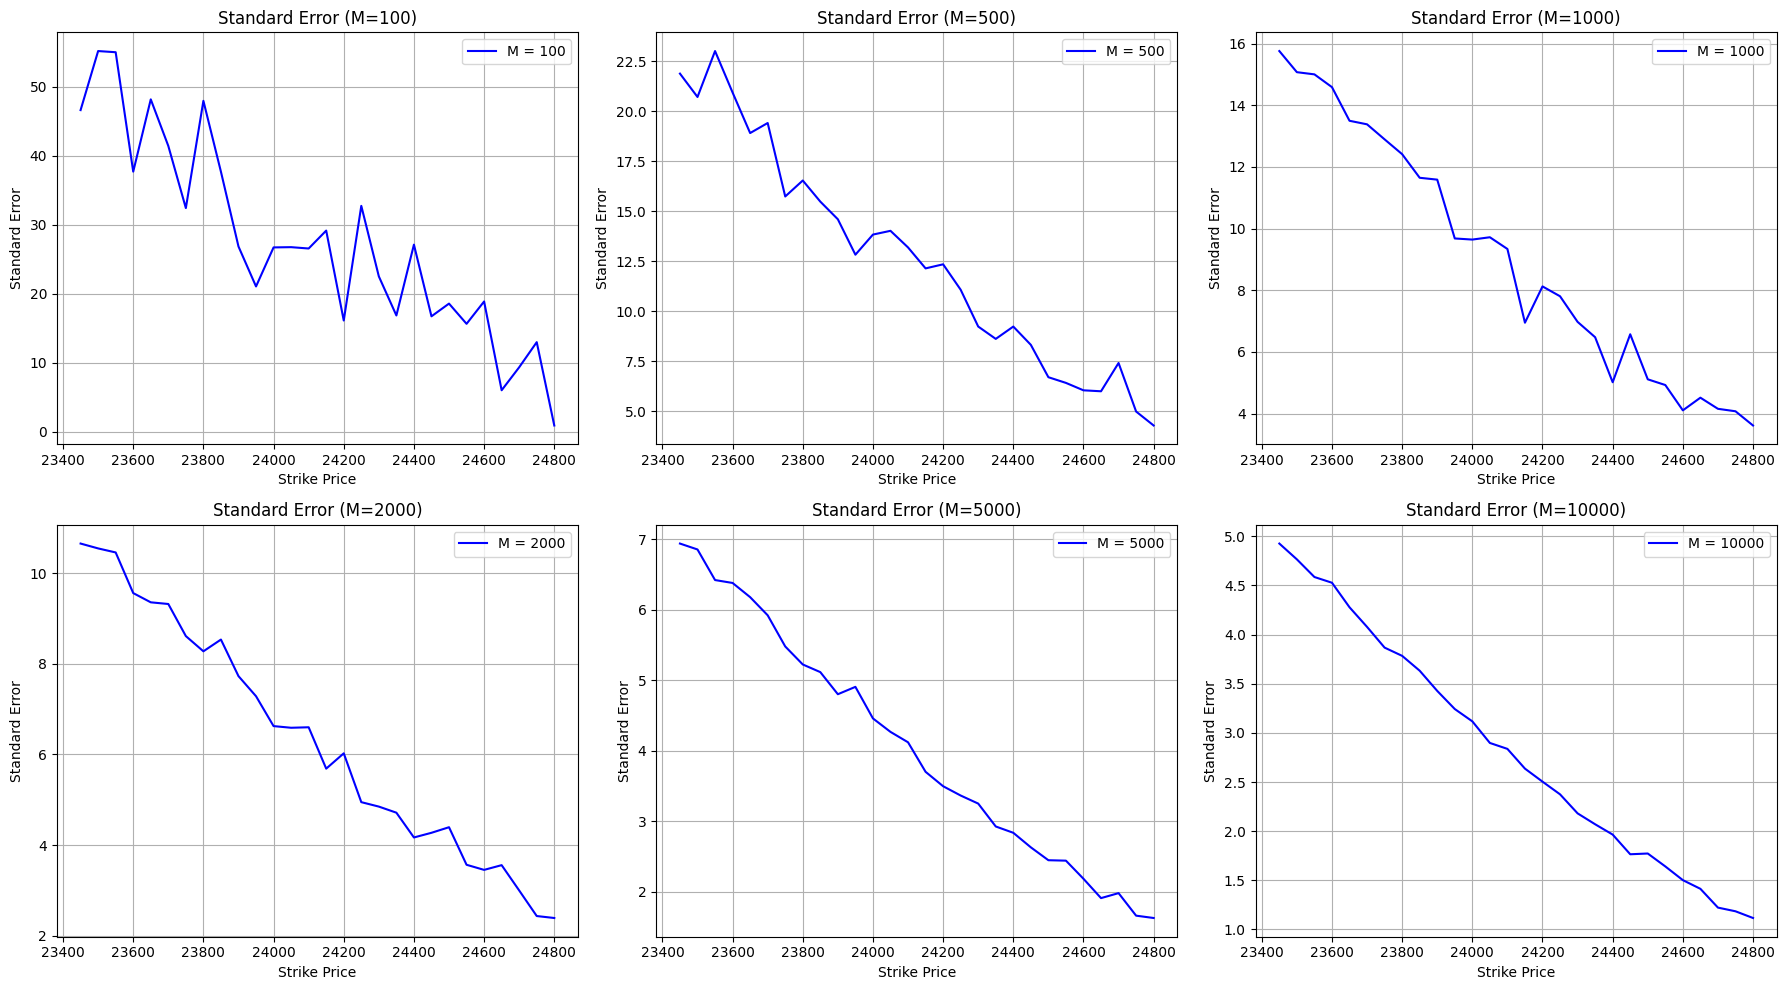

In [213]:
rows = (len(M_values) + 2) // 3  # Adjust for 3 columns per row
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
axes = axes.flatten()

for i, M in enumerate(M_values):
    axes[i].plot(df['strike'], df[f'err_call_M{M}'], label=f'M = {M}', color='blue')
    axes[i].set_title(f'Standard Error (M={M})', fontsize=12)
    axes[i].set_xlabel('Strike Price', fontsize=10)
    axes[i].set_ylabel('Standard Error', fontsize=10)
    axes[i].grid(True)
    axes[i].legend()

for j in range(len(M_values), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [220]:
print(df[['strike', 'ltp_call',  'mcs_call_price_M10000', 'err_call_M10000']])

    strike  ltp_call  mcs_call_price_M10000  err_call_M10000
37   23450    347.30             355.379833         4.926023
38   23500    320.15             330.436276         4.765205
39   23550    294.10             304.521922         4.585672
40   23600    270.35             273.211191         4.527397
41   23650    245.75             261.316994         4.277717
42   23700    224.35             238.154569         4.078052
43   23750    204.05             216.979475         3.867465
44   23800    183.75             202.215988         3.783558
45   23850    166.40             182.934335         3.632418
46   23900    149.50             176.150920         3.427044
47   23950    134.40             145.086515         3.242746
48   24000    121.05             140.205411         3.117430
49   24050    107.00             126.012482         2.897608
50   24100     95.00             112.618172         2.837263
51   24150     84.60              99.273267         2.636482
52   24200     74.70    

# Antithetic Variable Technique
 A very large number of trials is usually necessary to estimate the value of the derivative with reasonable accuracy. 
 This is very expensive in terms of computation time.

 In the antithetic variable technique, a simulation trial involves calculating two values of
the derivative. The first value f1 is calculated in the usual way; the second value f2 is
calculated by changing the sign of all the random samples from standard normal
distributions. (If is a sample used to calculate f1, then is the corresponding sample
used to calculate f2.) The sample value of the derivative calculated from a simulation
trial is the average of f1 and f2. This works well because when one value is above the
true value, the other tends to be below, and vice versa.
Denote f as the average of f1 and f2 :
f  =(f1 + f2)/2

The final estimate of the value of the derivative is the average of the f ’s. If w is the
standard deviation of the f ’s, and M is the number of simulation trials (i.e., the number
of pairs of values calculated), then the standard error of the estimate is
SE = w/M

This is usually much less than the standard error calculated using 2M random trials.

Let's write an option on asset $S_1$ and another option on asset $S_2$ that is perfectly negatively correlated with $S_1$ and which currently has the same price. $S_1$ and $S_2$ satisfy the following Stochastic Differential Equations:

$\large dS_{1,t} = rdS_{1,t}dt+\sigma dS_{1,t}dz_t$

$\large dS_{2,t} = rdS_{2,t}dt-\sigma dS_{2,t}dz_t$

Since the price and volatility of the two assets are identical, so is the value of these two options. However, the variance of a portfolio pay-off containing both of these contracts is much less than the variance of the pay-off of each individual contract. In essence we are removing the large spike in probability distribution of a single contract pay-off. i.e. Basic Intuition: when one option pays out, the other does not.

## Benefits of Antithetic Variance Reduction

1. By using pairs $(\epsilon_i, -\epsilon_i)$ in the simulation we can now achieve a more accurate estimate from M pairs of $(C_{T,i}, \bar{C}_{T,i})$ than from 2M of ${C}_{T,i}$.

2. It is also computationally cheaper to generate the pair $(C_{T,i}, \bar{C}_{T,i})$ than two instances of $C_{T,i}$

3. Method also ensures that mean of the normally distributed samples $\epsilon$ is exactly zero with helps improve the simulation

In [20]:
import numpy as np

class MonteCarloAntithetic:
    def __init__(self, N, M, S, K, r, sigma, T):
        """
        N: number of discrete time steps
        M: number of simulation pairs (trials)
        S: initial stock price
        K: strike price
        r: risk-free rate
        sigma: volatility
        T: time to maturity
        """
        self.N = N
        self.M = M
        self.S = S
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.dt = T / N  # Time step

    def simulate_antithetic_paths(self):
        """
        Simulate M paths of stock prices for two perfectly negatively correlated assets.
        Returns arrays of terminal prices (S1_T, S2_T) for both assets.
        """
        # Generate random normal increments for all paths
        Z = np.random.normal(0, 1, (self.M, self.N))  # Shape: (M, N)
        lnS1 = np.log(self.S) + np.cumsum(
            (self.r - 0.5 * self.sigma ** 2) * self.dt + self.sigma * np.sqrt(self.dt) * Z,
            axis=1
        )
        lnS2 = np.log(self.S) + np.cumsum(
            (self.r - 0.5 * self.sigma ** 2) * self.dt - self.sigma * np.sqrt(self.dt) * Z,
            axis=1
        )
        # Return the terminal stock prices
        return np.exp(lnS1[:, -1]), np.exp(lnS2[:, -1])  # Final column for S1 and S2

    def price_call(self):
        """
        Calculate the price of a call option using antithetic variates.
        """
        S1_T, S2_T = self.simulate_antithetic_paths()
        
        # Calculate payoffs for both assets
        CT1 = np.maximum(S1_T - self.K, 0)
        CT2 = np.maximum(S2_T - self.K, 0)
        
        # Average payoffs
        CT = (CT1 + CT2) / 2
        
        # Discounted price and standard error
        price = np.exp(-self.r * self.T) * np.mean(CT)
        standard_error = np.exp(-self.r * self.T) * np.std(CT, ddof=1) / np.sqrt(self.M)
        return price, standard_error

    def price_put(self):
        """
        Calculate the price of a put option using antithetic variates.
        """
        S1_T, S2_T = self.simulate_antithetic_paths()
        
        # Calculate payoffs for both assets
        PT1 = np.maximum(self.K - S1_T, 0)
        PT2 = np.maximum(self.K - S2_T, 0)
        
        # Average payoffs
        PT = (PT1 + PT2) / 2
        
        # Discounted price and standard error
        price = np.exp(-self.r * self.T) * np.mean(PT)
        standard_error = np.exp(-self.r * self.T) * np.std(PT, ddof=1) / np.sqrt(self.M)
        return price, standard_error


In [28]:
#Example with low S and K values
#If we increase S and K then error will increase due to increased sensitivity of price fluctuations
#meaning that small changes in the simulated price path can lead to larger changes in the option value, resulting in a larger potential for error in the calculation.

# initial derivative parameters
S = 101.15          #stock price
K = 98.01           #strike price
vol = annual_volatility        #volatility (%)
#use standard deviation of returns 
r = 0.01            #risk-free rate (%)
N = 10              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
M = 1000            #number of simulations
import datetime

T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
MC=MonteCarloAntithetic(N,M,S,K,r,vol,T)
call_price=MC.price_call()
print(call_price[0])
print(call_price[1])


3.5936582169052773
0.025316404243443773


In [35]:
if __name__ == "__main__":
    #Testing on nifty
    # Example parameters
    S0 = 23707.90    # Current stock price
    K = 23700.00     # Strike price
    T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
    r = 0.06857    # Risk-free rate (6.857%)
    sigma = annual_volatility # Volatility 
    N = 100              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
    M = 5000            #number of simulations  (n simulations of MoneCarloAntithetic is equivalent to 2n simulations of MonteCarlo) 
    # Create Black-Scholes model instance
    mcs = MonteCarloAntithetic(N,M,S0, K, T, r, sigma)
    # Calculate option prices
    call_price, call_se  = mcs.price_call()
    put_price, put_se = mcs.price_put()
    # Print results
    print(f"Parameters:")
    print(f"Stock Price (S0): {S0}")
    print(f"Strike Price (K): {K}")
    print(f"Time to Expiration (T): {T} years")
    print(f"Risk-free Rate (r): {r*100}%")
    print(f"Volatility (σ): {sigma*100}%")
    print(f"\nOption Prices:")
    print(f"Number of Simulations: {M}")
    print(f"Number of Time Steps: {N}")
    print(f"Call Option Price: {call_price:.2f}")
    print(f"Put Option Price: {put_price:.2f}")
    print(f"\nStandard Errors:")
    print(f"Call Option: {call_se:.6f}")
    print(f"Put Option: {put_se:.6f}")




Parameters:
Stock Price (S0): 23707.9
Strike Price (K): 23700.0
Time to Expiration (T): 0.06575342465753424 years
Risk-free Rate (r): 6.857%
Volatility (σ): 14.283458029563084%

Option Prices:
Number of Simulations: 5000
Number of Time Steps: 100
Call Option Price: 373.82
Put Option Price: 143.65

Standard Errors:
Call Option: 2.446432
Put Option: 2.296094


In [38]:
import requests
import pandas as pd

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
response = session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies

response = session.get(url, headers=headers)
data = response.json() # Parse JSON data

"""
data is a dictionary with keys: 'records' and 'filtered'

records contains complete, unfiltered data from the Nifty Option Chain API.
Structure:
data: A list of all option chain entries (calls and puts) across various expiry dates and strike prices.
expiryDates: A list of all available expiry dates.
timestamp: The timestamp of when the data was fetched.
underlyingValue: The current price of the NIFTY index.

filtered contains a pre-filtered subset of the option chain data. It focuses on the nearest expiry date and relevant strike prices close to the current NIFTY value
Structure:
CE: Filtered Call Option data.
PE: Filtered Put Option data.
data: Limited to strikes near the current NIFTY index (e.g., ±10 strikes around the spot price).
"""

# User-defined expiry date
TARGET_EXPIRY = '30-Jan-2025'  # desired expiry date

# Parse data
options_data = []
for record in data['records']['data']: # record contains expiryDate, strikePrice, CE, PE
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:  # Filter by specific expiry date
        strike_price = record['strikePrice']
        ltp_call = record.get('CE', {}).get('lastPrice', None)  # Call Option LTP
        ltp_put = record.get('PE', {}).get('lastPrice', None)   # Put Option LTP
        iv_call = record.get('CE', {}).get('impliedVolatility', None)
        iv_put = record.get('PE', {}).get('impliedVolatility', None)
        options_data.append({
            'expiry_date': expiry_date,
            'strike': strike_price,
            'ltp_call': ltp_call,
            'ltp_put': ltp_put,
            'iv_call': iv_call,
            'iv_put': iv_put,
        })

# Convert to DataFrame
df = pd.DataFrame(options_data)
if df.empty:
    print(f"No data found for expiry date: {TARGET_EXPIRY}")
else:
    print(f"Data fetched successfully for expiry date: {TARGET_EXPIRY}")

print(df)


Data fetched successfully for expiry date: 30-Jan-2025
    expiry_date  strike  ltp_call  ltp_put  iv_call  iv_put
0   30-Jan-2025   21600   1906.40     8.70     0.00   18.70
1   30-Jan-2025   21650   2942.45     9.80     0.00   18.64
2   30-Jan-2025   21700   1817.15    11.15     0.00   18.60
3   30-Jan-2025   21750   2844.70    11.75     0.00   18.33
4   30-Jan-2025   21800   1731.25    11.90     0.00   17.93
..          ...     ...       ...      ...      ...     ...
94  30-Jan-2025   26300      4.40  2754.30    20.47   27.69
95  30-Jan-2025   26350      4.30  1738.15    20.72    0.00
96  30-Jan-2025   26400      3.90  2860.85    20.76   29.69
97  30-Jan-2025   26450      4.10  2461.25    21.19    0.00
98  30-Jan-2025   26500      4.05  2968.50    21.46   31.76

[99 rows x 6 columns]


In [39]:
S=data['records']['underlyingValue']    # Current stock price
r = 0.06857    # Risk-free rate (6.857%)
sigma = annual_volatility # Volatility 
expiry_date = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
today = dt.today()
T = (expiry_date - today).days / 365 + 1 / 365
N = 100              #number of time steps i.e number of discrete intervals (dt=T/N -> delta T)
M = 500            #number of simulations
df = df[(df['strike'] >= 23450) & (df['strike'] <= 24800)]
# Assuming price_call returns two values: (price, error)
df['mcs_call_price'], df['err_call'] = zip(*df['strike'].apply(
    lambda K: MonteCarloAntithetic(N, M, S, K, r, sigma, T).price_call())
)
df['mcs_put_price'], df['err_put'] = zip(*df['strike'].apply(
    lambda K: MonteCarloAntithetic(N, M, S, K, r, sigma, T).price_put())
)
df.columns
# MonteCarlo(N, M, 23700, 23600, r, sigma, T).price_call()

Index(['expiry_date', 'strike', 'ltp_call', 'ltp_put', 'iv_call', 'iv_put',
       'mcs_call_price', 'err_call', 'mcs_put_price', 'err_put'],
      dtype='object')

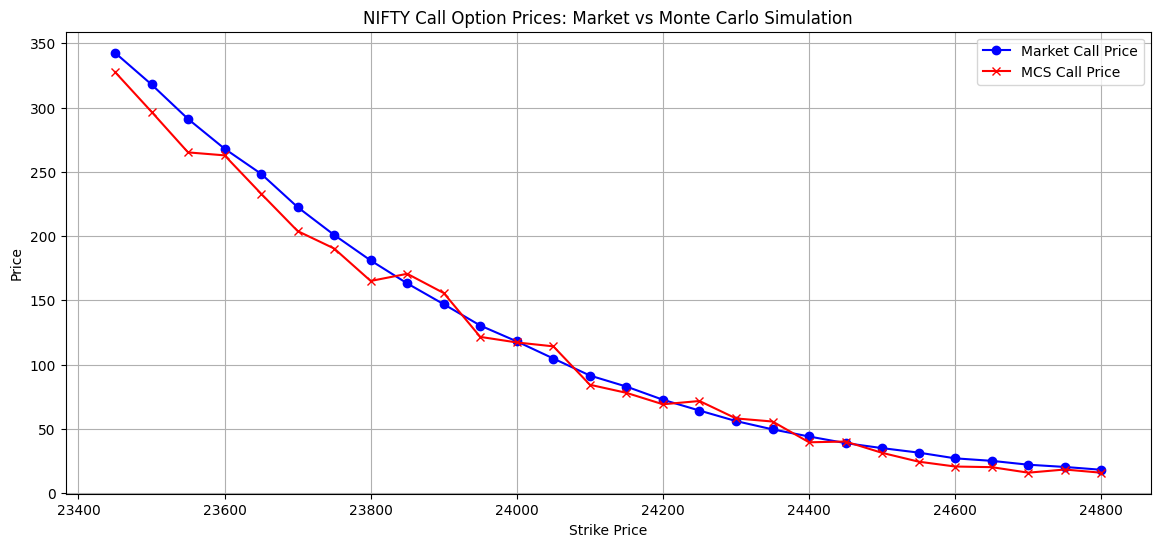

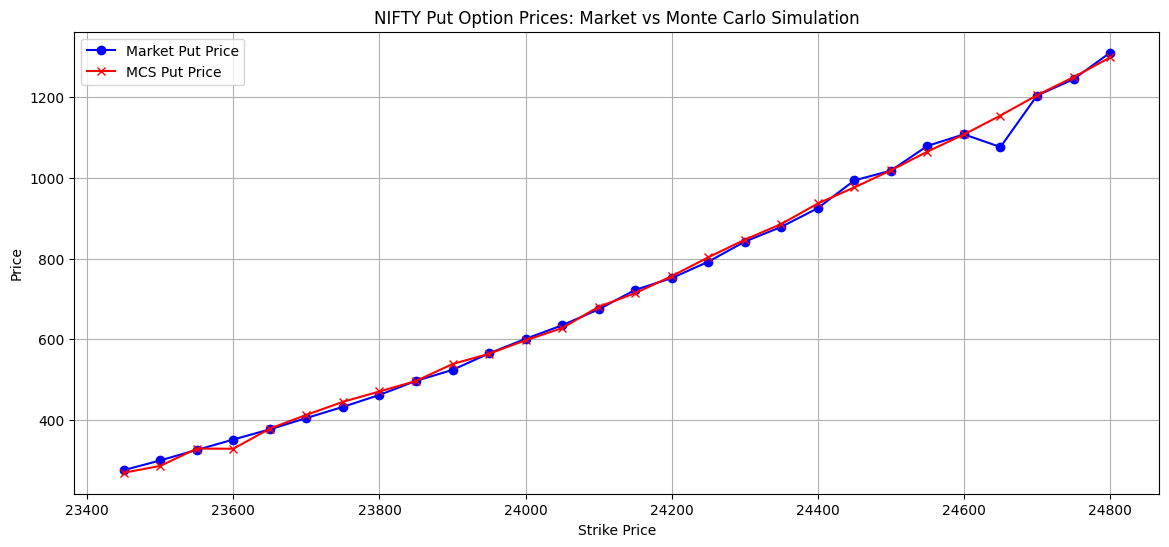

In [40]:
import matplotlib.pyplot as plt

# Plot Call Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price', color='b')
plt.plot(df['strike'], df['mcs_call_price'], 'x-', label='MCS Call Price', color='r')
plt.title('NIFTY Call Option Prices: Market vs Monte Carlo Simulation')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Put Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_put'], 'o-', label='Market Put Price', color='b')
plt.plot(df['strike'], df['mcs_put_price'], 'x-', label='MCS Put Price', color='r')
plt.title('NIFTY Put Option Prices: Market vs Monte Carlo Simulation')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


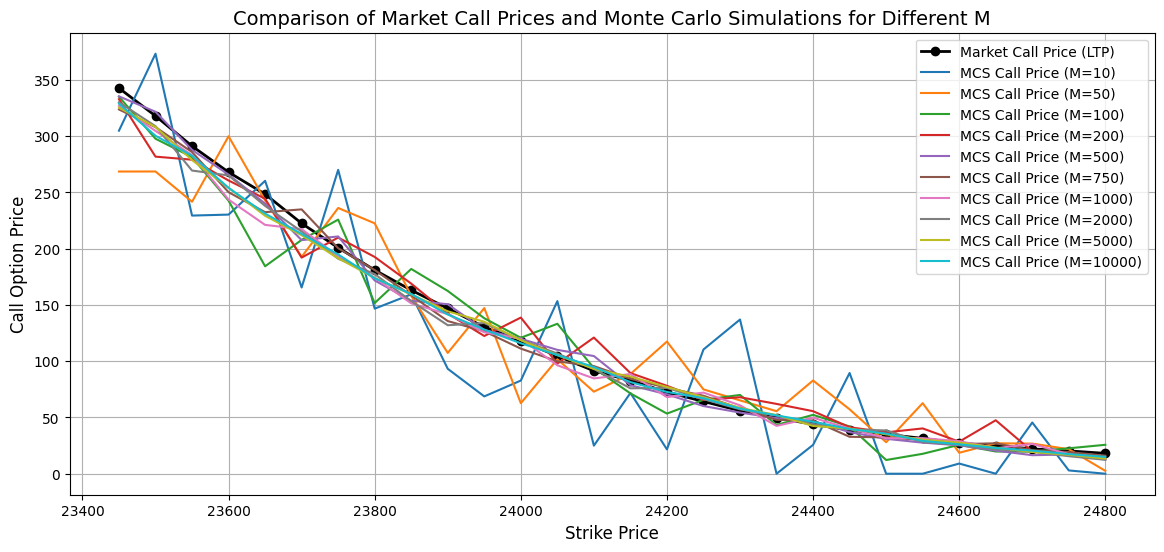

In [41]:
# Define a range of N values to test
M_values = [10, 50, 100, 200,500,750,1000,2000,5000,10000]  # Different numbers of time steps

# Create a new DataFrame to store mcs_call_price for each N
for M in M_values:
    df[f'mcs_call_price_M{M}'] = df['strike'].apply(
        lambda K: MonteCarloAntithetic(N, M, S, K, r, sigma, T).price_call()[0]
    )

# Plot the call option prices
plt.figure(figsize=(14, 6))

# Plot the actual market prices (ltp_call)
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black', linewidth=2)

# Plot the Monte Carlo prices for different N values
for M in M_values:
    plt.plot(df['strike'], df[f'mcs_call_price_M{M}'], label=f'MCS Call Price (M={M})')

# Add title and labels
plt.title('Comparison of Market Call Prices and Monte Carlo Simulations for Different M', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [42]:
import plotly.graph_objects as go

fig = go.Figure()

# Add market prices
fig.add_trace(go.Scatter(x=df['strike'], y=df['ltp_call'], mode='lines+markers',
                         name='Market Call Price (LTP)', line=dict(color='black', width=2)))

# Add Monte Carlo prices for each M
for M in M_values:
    fig.add_trace(go.Scatter(x=df['strike'], y=df[f'mcs_call_price_M{M}'], mode='lines',
                             name=f'MCS Call Price (M={M})'))

# Update layout for better visualization
fig.update_layout(
    title='Comparison of Market Call Prices and Monte Carlo Simulations for Different M',
    xaxis_title='Strike Price',
    yaxis_title='Call Option Price',
    legend_title='Price Source',
    template='plotly_white'
)

fig.show()


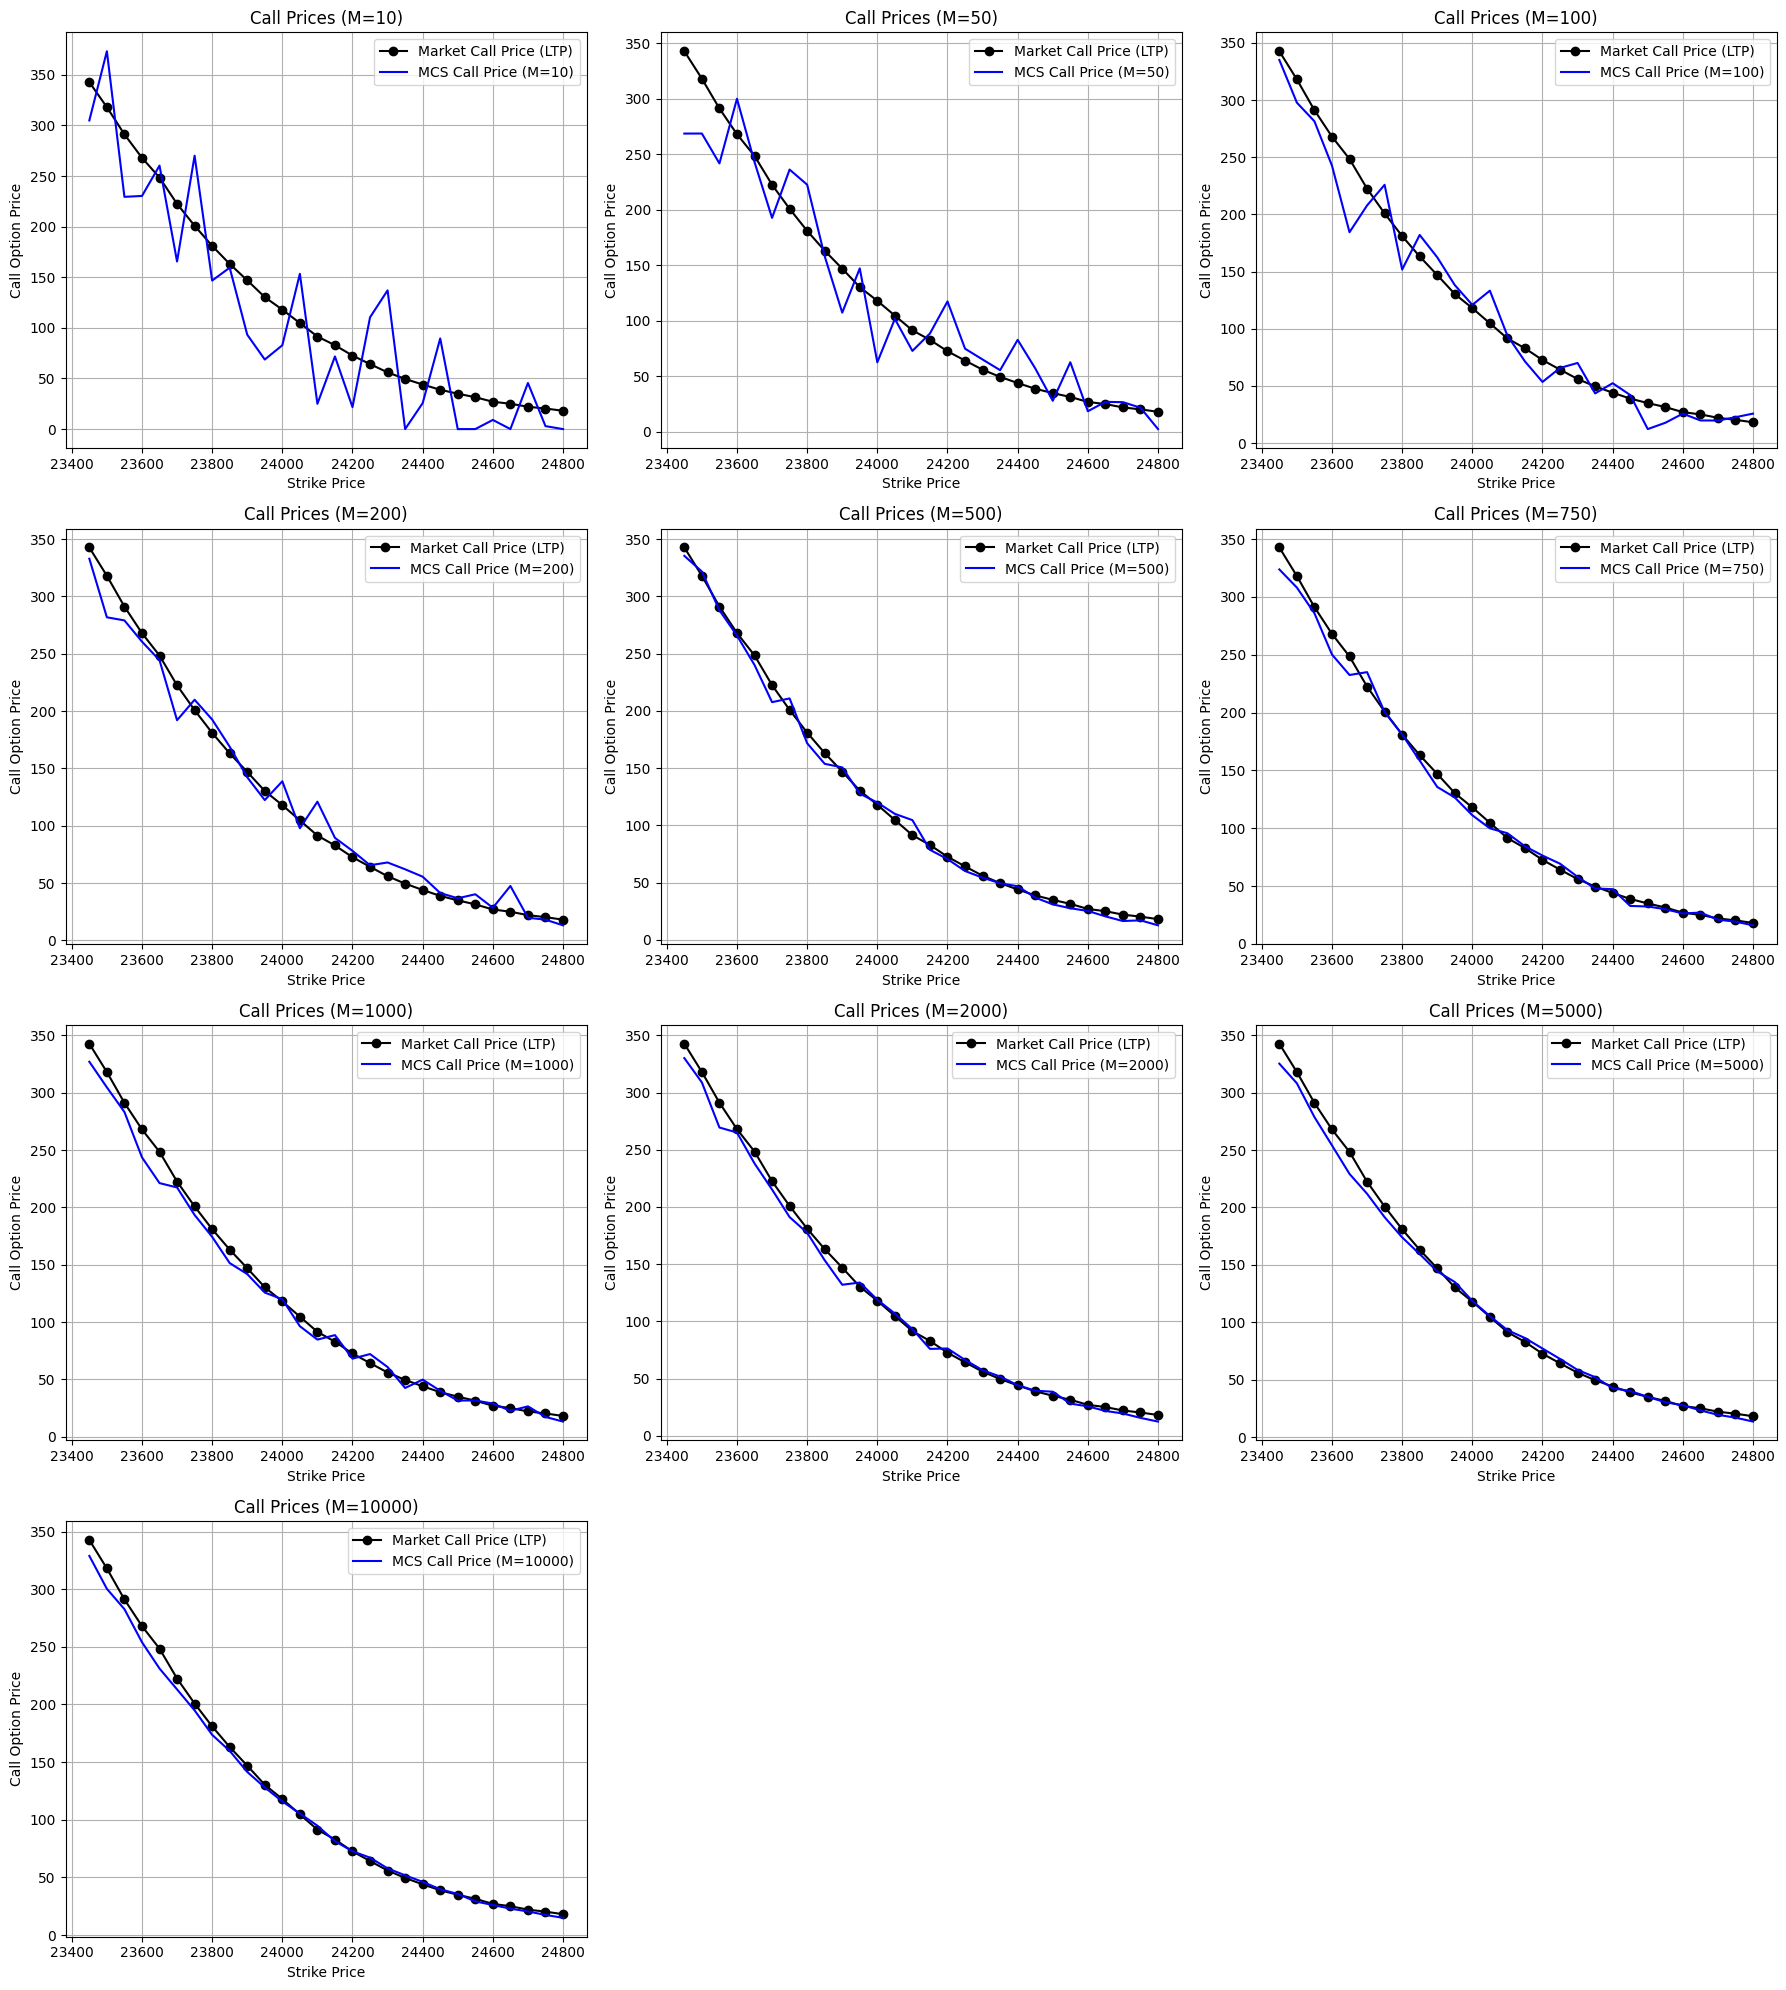

In [43]:
import matplotlib.pyplot as plt

# Number of subplots based on N_values
rows = (len(M_values) + 2) // 3  # Adjust to fit 3 columns per row

fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))  # 3 columns
axes = axes.flatten()

# Plot each N in a separate subplot
for i, M in enumerate(M_values):
    axes[i].plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black')
    axes[i].plot(df['strike'], df[f'mcs_call_price_M{M}'], label=f'MCS Call Price (M={M})', color='blue')
    axes[i].set_title(f'Call Prices (M={M})', fontsize=12)
    axes[i].set_xlabel('Strike Price', fontsize=10)
    axes[i].set_ylabel('Call Option Price', fontsize=10)
    axes[i].legend()
    axes[i].grid(True)

# Hide unused subplots
for j in range(len(M_values), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


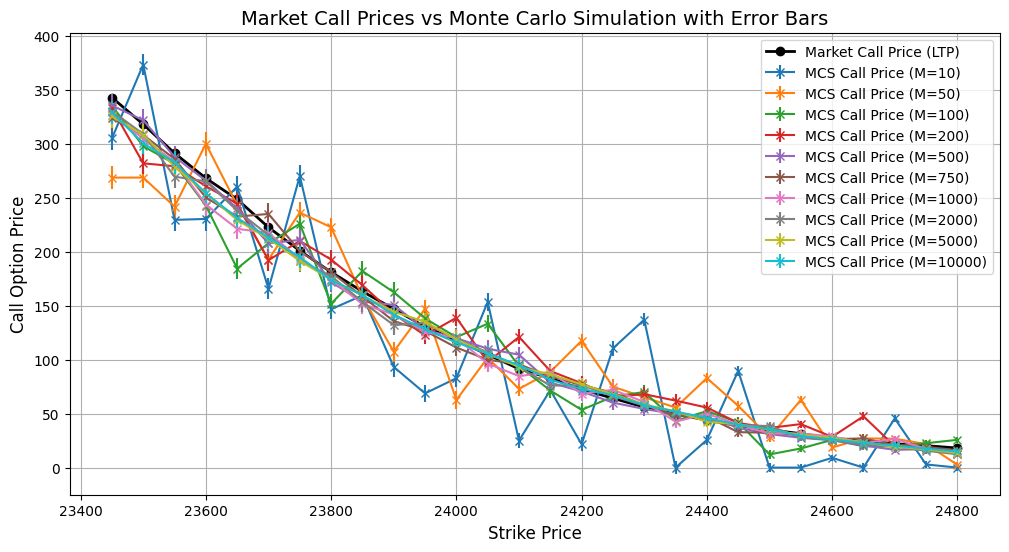

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot market prices
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price (LTP)', color='black', linewidth=2)

# Plot Monte Carlo prices with error bars for selected N values
selected_M = [10, 50, 100, 200,500,750,1000,2000,5000,10000]  # Different numbers of time steps

for M in selected_M:
    plt.errorbar(df['strike'], df[f'mcs_call_price_M{M}'], yerr=df['err_call'], fmt='x-', label=f'MCS Call Price (M={M})')

# Add titles and legend
plt.title('Market Call Prices vs Monte Carlo Simulation with Error Bars', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


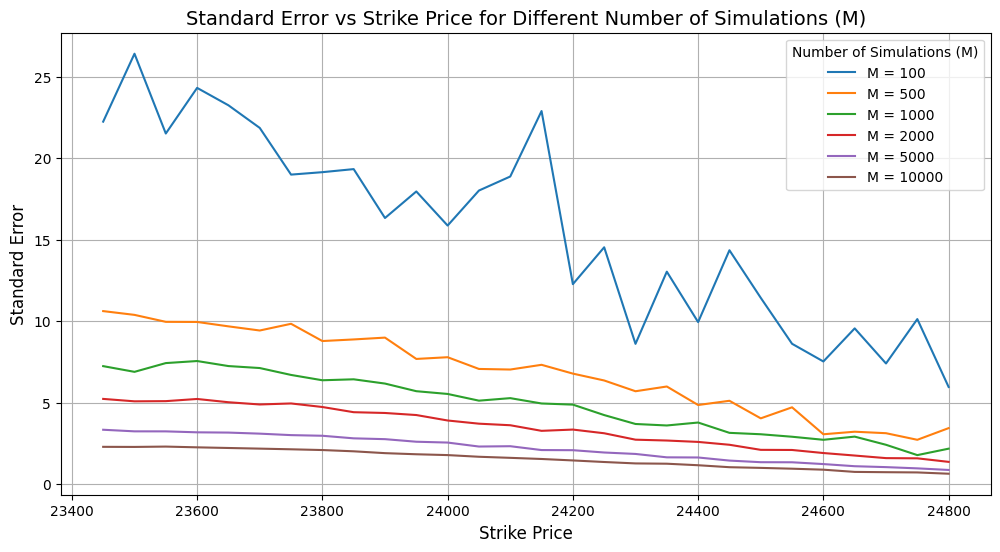

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Define different M values (number of simulations)
M_values = [100, 500, 1000, 2000, 5000, 10000]

# Calculate standard errors for each M and store them in new columns
for M in M_values:
    df[f'err_call_M{M}'] = df['strike'].apply(
        lambda K: MonteCarloAntithetic(N, M, S, K, r, sigma, T).price_call()[1]
    )

# Plot standard error vs strike price for different M values
plt.figure(figsize=(12, 6))
for M in M_values:
    plt.plot(df['strike'], df[f'err_call_M{M}'], label=f'M = {M}')

# Add titles and labels
plt.title('Standard Error vs Strike Price for Different Number of Simulations (M)', fontsize=14)
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Standard Error', fontsize=12)
plt.legend(title='Number of Simulations (M)', fontsize=10)
plt.grid(True)
plt.show()


In [46]:
import plotly.graph_objects as go

fig = go.Figure()
for M in M_values:
    fig.add_trace(go.Scatter(x=df['strike'], y=df[f'err_call_M{M}'], mode='lines',
                             name=f'Standard Error (M={M})'))

fig.update_layout(
    title='Standard Error vs Strike Price for Different M',
    xaxis_title='Strike Price',
    yaxis_title='Standard Error',
    legend_title='Simulations (M)',
    template='plotly_white'
)
fig.show()


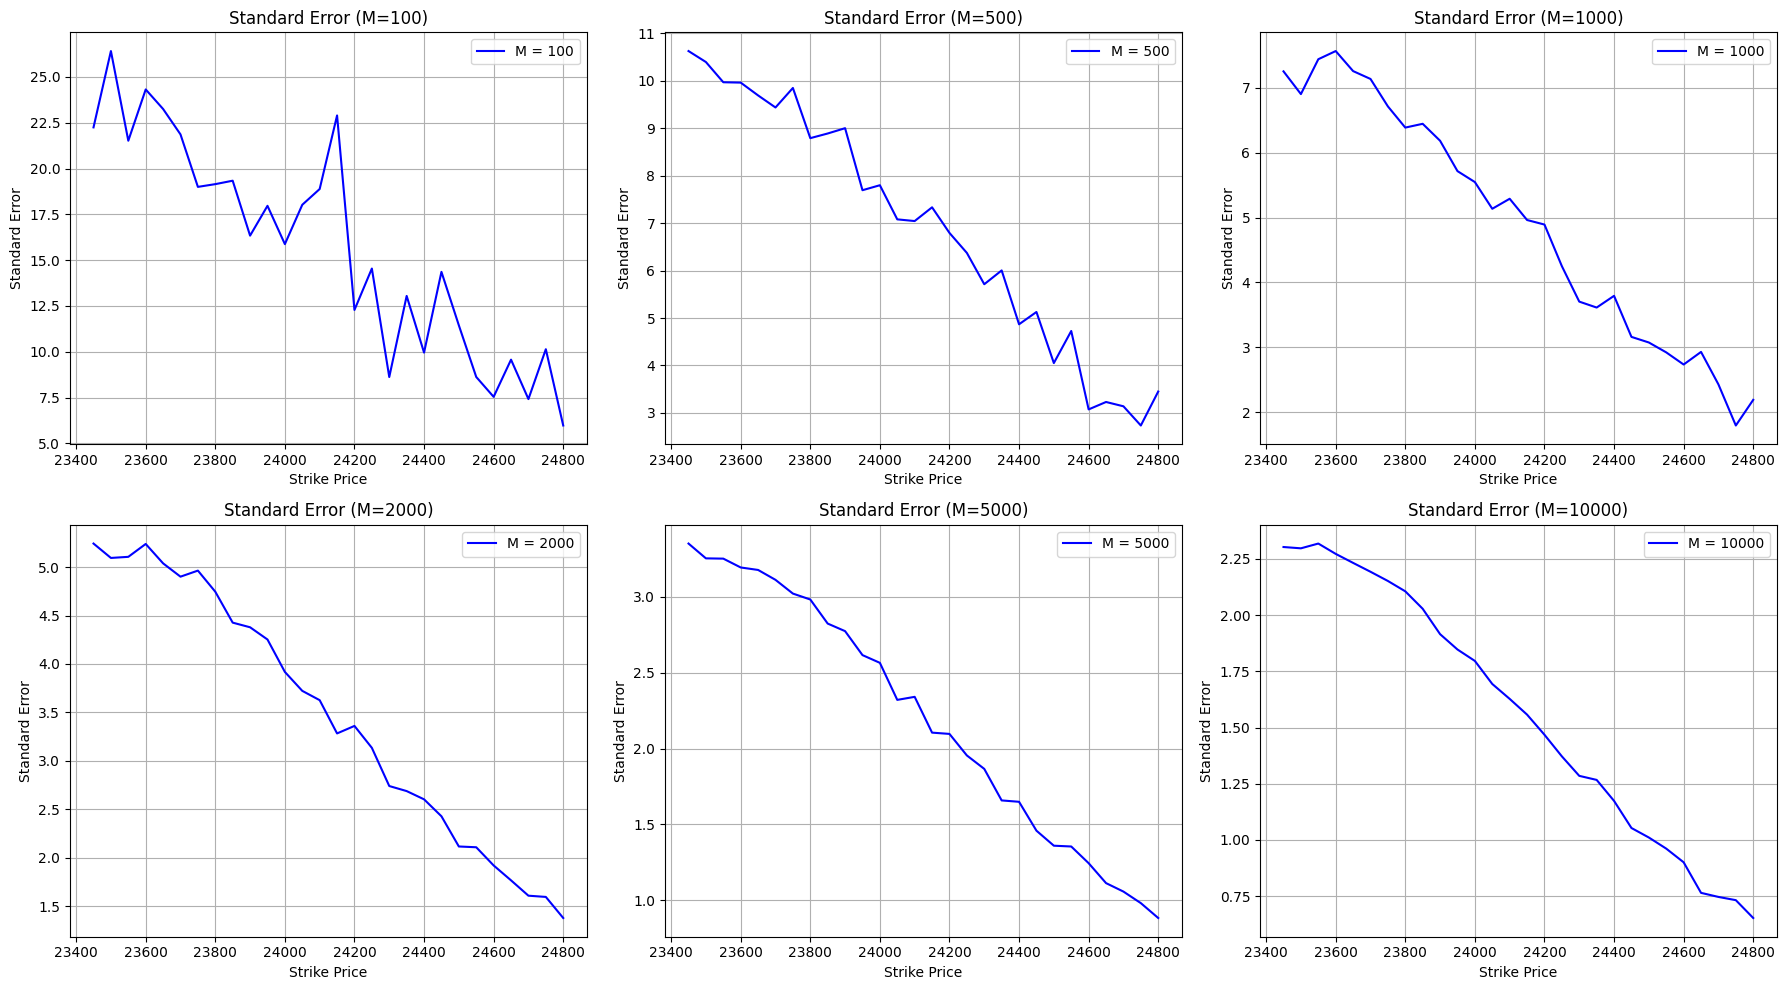

In [47]:
rows = (len(M_values) + 2) // 3  # Adjust for 3 columns per row
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
axes = axes.flatten()

for i, M in enumerate(M_values):
    axes[i].plot(df['strike'], df[f'err_call_M{M}'], label=f'M = {M}', color='blue')
    axes[i].set_title(f'Standard Error (M={M})', fontsize=12)
    axes[i].set_xlabel('Strike Price', fontsize=10)
    axes[i].set_ylabel('Standard Error', fontsize=10)
    axes[i].grid(True)
    axes[i].legend()

for j in range(len(M_values), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
